<a href="https://colab.research.google.com/github/KIRANVVIT/CODE-FOBE-PROBLEM-STATEMENTS/blob/main/week15_practice_kiran.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week 15 Understanding POST and PUT API**

**POST (Create a Product) When to Use POST? ✅ When inserting new data into the database.**

POST requests cannot be tested directly from the browser address bar because browsers mainly support GET requests through URLs.

That is why we use ReqBin to test POST APIs by sending JSON data to the Flask server.

201 Created - When creating a new resource

204 No Content - When deleting or updating without returning data

400 Bad Request - For validation errors

404 Not Found - When resource doesn't exist

500 Internal Server Error - For server errors

In [ ]:
#            POST -  inserting new data into the database.
# IMPORT FLASK, REQUEST, JOSNIFY AND IMPORT SQLITE3 FOR DB
# CREATE FLASK INSTANCE "app"
# 1. initialising products data base init_db()
# 2. with in it , start connecting to data base
# 3. create a table in the db
# 4. insert rows into the table if there exists none
# 5. db actions are done. commit it and close the connection
# 6. Now call the db , so that a table is created with rows in it.
# 7. Since table is created, we need API to access the data
# 8. Define home route , i.e., message on the home page
# 9. Define each function you need to perform along with its app route
#10. fxn1- get all products from the data base, open conn-define function get method-close conn-jsonify the result
#11. fxn2- get product by id, open conn-code to get prod by id get method- close conn-jsonify the output
#12. fxn3- add new product to the table in db , open conn -code to add new row post method REQUEST LIBRARY- close conn-josonify output
#RUN THE FLASK INSTANCE WITH LOCAL HOST, PORT, AND DEBUG STATUS

# IMPORT FLASK, REQUEST, JOSNIFY AND IMPORT SQLITE3 FOR DB
from flask import Flask, request, jsonify
import sqlite3

# CREATE FLASK INSTANCE "app"
app = Flask(__name__)

                        # 1. initialising products data base init_db()
def init_db():
                         # 2. with in it , start connecting to data base
  conn = sqlite3.connect('products.db')
  cursor = conn.cursor()
                         # 3. create a table in the db
  cursor.execute('''
  CREATE TABLE IF NOT EXISTS products(
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        name TEXT NOT NULL,
        price REAL NOT NULL,
        stock INTEGER NOT NULL
      )
  ''')
                         # 4. insert rows into the table if there exists none, after the action is done, commit and close the conn
  cursor.execute('SELECT COUNT(*) FROM products')
  count = cursor.fetchone()[0]

  if count == 0:
    cursor.executemany('''
        INSERT INTO products(name, price, stock)
          VALUES (?,?,?)
    ''',[
         ("Laptop", 75000, 10),
         ("Smartphone", 40000, 20),
         ("Headphones", 2000, 50)
        ]
    )
                        # 5. db actions are done. commit it and close the connection
  conn.commit()
  conn.close()
                        # 6. Now call the db , so that a table is created with rows in it.
init_db()

                        # 7. Since table is created, we need API to access the data
                        # 8. Define home route , i.e., message on the home page
@app.route('/')
def home():
  return "Welcome to the Flask CRUD API!<b> Use /products to fetch all products.<b>Use /products/<id> to fetch product by id "

                          # 9. Define each function you need to perform along with its app route
                    #10. fxn1- get all products from the data base,"" open conn""-define function get method-""close conn-""jsonify the result
@app.route('/products', methods=['GET'])
def get_all_products():
  conn = sqlite3.connect('products.db')
  cursor = conn.cursor()

  cursor.execute('SELECT * FROM products')
  all_products = cursor.fetchall()

  products_list = [
      {
        'id': row[0],
        'name': row[1],
        'price': row[2],
        'stock': row[3]
      }
      for row in all_products
      ]

  conn.close()

  return jsonify(products_list), 200

                                  #11. fxn2- get product by id,"" open conn"""-code to get prod by id get method-"""" close conn-"""jsonify the output
@app.route('/products/<int:id>', methods=['GET'])
def get_product_by_id(id):
  conn = sqlite3.connect('products.db')
  cursor = conn.cursor()

  cursor.execute('SELECT * FROM products WHERE id = ?', (id,))
  single_product = cursor.fetchone()

  conn.close()

  if single_product:
    return jsonify(
        {
          'id': single_product[0],
          'name': single_product[1],
          'price': single_product[2],
          'stock': single_product[3]
        }
    ), 200

  return jsonify({'message': 'Product not found'}), 404

                                #12. fxn3- add new product to the table in db , open conn -code to add new row post method REQUEST LIBRARY- close conn-josonify output
@app.route('/products', methods=['POST'])
def add_product():
  data = request.get_json()

  conn = sqlite3.connect('products.db')
  cursor = conn.cursor()

  cursor.execute('INSERT INTO products(name, price, stock) VALUES(?,?,?)',
    (
      data['name'], data['price'], data['stock']
    )
  )

  conn.commit()
  new_product_id = cursor.lastrowid
  conn.close()

  return jsonify(
    {
      "message": "Product added successfully!",
      "product": {
          "id": new_product_id,
          "name": data['name'],
          "price": data['price'],
          "stock": data['stock']
        }
     }
  ), 201

#RUN THE FLASK INSTANCE WITH LOCAL HOST, PORT, AND DEBUG STATUS

if __name__ == '__main__':
  app.run(host='0.0.0.0', port=5000, debug=True)



# **Understanding and Implementing PUT APIs**

**PUT is used when you want to modify or replace an existing record instead of creating a new one.**

In [ ]:
#            POST -  inserting new data into the database.
# IMPORT FLASK, REQUEST, JOSNIFY AND IMPORT SQLITE3 FOR DB
# CREATE FLASK INSTANCE "app"
# 1. initialising products data base init_db()
# 2. with in it , start connecting to data base
# 3. create a table in the db
# 4. insert rows into the table if there exists none
# 5. db actions are done. commit it and close the connection
# 6. Now call the db , so that a table is created with rows in it.
# 7. Since table is created, we need API to access the data
# 8. Define home route , i.e., message on the home page
# 9. Define each function you need to perform along with its app route
#10. fxn1- get all products from the data base, open conn-define function get method-close conn-jsonify the result
#11. fxn2- get product by id, open conn-code to get prod by id get method- close conn-jsonify the output
#12. fxn3- add new product to the table in db , open conn -code to add new row post method REQUEST LIBRARY- close conn-josonify output
#RUN THE FLASK INSTANCE WITH LOCAL HOST, PORT, AND DEBUG STATUS

# IMPORT FLASK, REQUEST, JOSNIFY AND IMPORT SQLITE3 FOR DB
from flask import Flask, request, jsonify
import sqlite3

# CREATE FLASK INSTANCE "app"
app = Flask(__name__)

                        # 1. initialising products data base init_db()
def init_db():
                         # 2. with in it , start connecting to data base
  conn = sqlite3.connect('products.db')
  cursor = conn.cursor()
                         # 3. create a table in the db
  cursor.execute('''
  CREATE TABLE IF NOT EXISTS products(
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        name TEXT NOT NULL,
        price REAL NOT NULL,
        stock INTEGER NOT NULL
      )
  ''')
                         # 4. insert rows into the table if there exists none, after the action is done, commit and close the conn
  cursor.execute('SELECT COUNT(*) FROM products')
  count = cursor.fetchone()[0]

  if count == 0:
    cursor.executemany('''
        INSERT INTO products(name, price, stock)
          VALUES (?,?,?)
    ''',[
         ("Laptop", 75000, 10),
         ("Smartphone", 40000, 20),
         ("Headphones", 2000, 50)
        ]
    )
                        # 5. db actions are done. commit it and close the connection
  conn.commit()
  conn.close()
                        # 6. Now call the db , so that a table is created with rows in it.
init_db()

                        # 7. Since table is created, we need API to access the data
                        # 8. Define home route , i.e., message on the home page
@app.route('/')
def home():
  return "Welcome to the Flask CRUD API!<b> Use /products to fetch all products.<b>Use /products/<id> to fetch product by id "

                          # 9. Define each function you need to perform along with its app route
                    #10. fxn1- get all products from the data base,"" open conn""-define function get method-""close conn-""jsonify the result
@app.route('/products', methods=['GET'])
def get_all_products():
  conn = sqlite3.connect('products.db')
  cursor = conn.cursor()

  cursor.execute('SELECT * FROM products')
  all_products = cursor.fetchall()

  products_list = [
      {
        'id': row[0],
        'name': row[1],
        'price': row[2],
        'stock': row[3]
      }
      for row in all_products
      ]

  conn.close()

  return jsonify(products_list), 200

                                  #11. fxn2- get product by id,"" open conn"""-code to get prod by id get method-"""" close conn-"""jsonify the output
@app.route('/products/<int:id>', methods=['GET'])
def get_product_by_id(id):
  conn = sqlite3.connect('products.db')
  cursor = conn.cursor()

  cursor.execute('SELECT * FROM products WHERE id = ?', (id,))
  single_product = cursor.fetchone()

  conn.close()

  if single_product:
    return jsonify(
        {
          'id': single_product[0],
          'name': single_product[1],
          'price': single_product[2],
          'stock': single_product[3]
        }
    ), 200

  return jsonify({'message': 'Product not found'}), 404

                                #12. fxn3- add new product to the table in db , open conn -code to add new row post method REQUEST LIBRARY- close conn-josonify output
@app.route('/products', methods=['POST'])
def add_product():
  data = request.get_json()

  conn = sqlite3.connect('products.db')
  cursor = conn.cursor()

  cursor.execute('INSERT INTO products(name, price, stock) VALUES(?,?,?)',
    (
      data['name'], data['price'], data['stock']
    )
  )

  conn.commit()
  new_product_id = cursor.lastrowid
  conn.close()

  return jsonify(
    {
      "message": "Product added successfully!",
      "product": {
          "id": new_product_id,
          "name": data['name'],
          "price": data['price'],
          "stock": data['stock']
        }
     }
  ), 201

# PUT METHOD - UPDATING THE EXISTING DATA
@app.route('/products/<int:product_id>', methods=['PUT'])
def update_product(product_id):
    data = request.get_json()

    conn = sqlite3.connect('products.db')
    cursor = conn.cursor()

    cursor.execute('SELECT * FROM products WHERE id = ?', (product_id,))
    product = cursor.fetchone()

    if not product:
        conn.close()
        return jsonify({"error": "Product not found"}), 404

    cursor.execute('''
        UPDATE products
        SET name = ?, price = ?, stock = ?
        WHERE id = ?
    ''', (data['name'], data['price'], data['stock'], product_id))

    conn.commit()
    conn.close()

    return jsonify({
        "message": "Product updated successfully!",
        "product": {
            "id": product_id,
            "name": data['name'],
            "price": data['price'],
            "stock": data['stock']
        }
    }), 200


#RUN THE FLASK INSTANCE WITH LOCAL HOST, PORT, AND DEBUG STATUS

if __name__ == '__main__':
  app.run(host='0.0.0.0', port=5000, debug=True)



**Understanding DELETE API**

**DELETE: Remove a Product by ID ,,,
Delete All Products Using a DELETE API**

**permanently remove data from a database.**

In [ ]:
#            POST -  inserting new data into the database.
# IMPORT FLASK, REQUEST, JOSNIFY AND IMPORT SQLITE3 FOR DB
# CREATE FLASK INSTANCE "app"
# 1. initialising products data base init_db()
# 2. with in it , start connecting to data base
# 3. create a table in the db
# 4. insert rows into the table if there exists none
# 5. db actions are done. commit it and close the connection
# 6. Now call the db , so that a table is created with rows in it.
# 7. Since table is created, we need API to access the data
# 8. Define home route , i.e., message on the home page
# 9. Define each function you need to perform along with its app route
#10. fxn1- get all products from the data base, open conn-define function get method-close conn-jsonify the result
#11. fxn2- get product by id, open conn-code to get prod by id get method- close conn-jsonify the output
#12. fxn3- add new product to the table in db , open conn -code to add new row post method REQUEST LIBRARY- close conn-josonify output
#RUN THE FLASK INSTANCE WITH LOCAL HOST, PORT, AND DEBUG STATUS

# IMPORT FLASK, REQUEST, JOSNIFY AND IMPORT SQLITE3 FOR DB
from flask import Flask, request, jsonify
import sqlite3

# CREATE FLASK INSTANCE "app"
app = Flask(__name__)

                        # 1. initialising products data base init_db()
def init_db():
                         # 2. with in it , start connecting to data base
  conn = sqlite3.connect('products.db')
  cursor = conn.cursor()
                         # 3. create a table in the db
  cursor.execute('''
  CREATE TABLE IF NOT EXISTS products(
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        name TEXT NOT NULL,
        price REAL NOT NULL,
        stock INTEGER NOT NULL
      )
  ''')
                         # 4. insert rows into the table if there exists none, after the action is done, commit and close the conn
  cursor.execute('SELECT COUNT(*) FROM products')
  count = cursor.fetchone()[0]

  if count == 0:
    cursor.executemany('''
        INSERT INTO products(name, price, stock)
          VALUES (?,?,?)
    ''',[
         ("Laptop", 75000, 10),
         ("Smartphone", 40000, 20),
         ("Headphones", 2000, 50)
        ]
    )
                        # 5. db actions are done. commit it and close the connection
  conn.commit()
  conn.close()
                        # 6. Now call the db , so that a table is created with rows in it.
init_db()

                        # 7. Since table is created, we need API to access the data
                        # 8. Define home route , i.e., message on the home page
@app.route('/')
def home():
  return "Welcome to the Flask CRUD API!<b> Use /products to fetch all products.<b>Use /products/<id> to fetch product by id "

                          # 9. Define each function you need to perform along with its app route
                    #10. fxn1- get all products from the data base,"" open conn""-define function get method-""close conn-""jsonify the result
@app.route('/products', methods=['GET'])
def get_all_products():
  conn = sqlite3.connect('products.db')
  cursor = conn.cursor()

  cursor.execute('SELECT * FROM products')
  all_products = cursor.fetchall()

  products_list = [
      {
        'id': row[0],
        'name': row[1],
        'price': row[2],
        'stock': row[3]
      }
      for row in all_products
      ]

  conn.close()

  return jsonify(products_list), 200

                                  #11. fxn2- get product by id,"" open conn"""-code to get prod by id get method-"""" close conn-"""jsonify the output
@app.route('/products/<int:id>', methods=['GET'])
def get_product_by_id(id):
  conn = sqlite3.connect('products.db')
  cursor = conn.cursor()

  cursor.execute('SELECT * FROM products WHERE id = ?', (id,))
  single_product = cursor.fetchone()

  conn.close()

  if single_product:
    return jsonify(
        {
          'id': single_product[0],
          'name': single_product[1],
          'price': single_product[2],
          'stock': single_product[3]
        }
    ), 200

  return jsonify({'message': 'Product not found'}), 404

                                #12. fxn3- add new product to the table in db , open conn -code to add new row post method REQUEST LIBRARY- close conn-josonify output
@app.route('/products', methods=['POST'])
def add_product():
  data = request.get_json()

  conn = sqlite3.connect('products.db')
  cursor = conn.cursor()

  cursor.execute('INSERT INTO products(name, price, stock) VALUES(?,?,?)',
    (
      data['name'], data['price'], data['stock']
    )
  )

  conn.commit()
  new_product_id = cursor.lastrowid
  conn.close()

  return jsonify(
    {
      "message": "Product added successfully!",
      "product": {
          "id": new_product_id,
          "name": data['name'],
          "price": data['price'],
          "stock": data['stock']
        }
     }
  ), 201

# PUT METHOD - UPDATING THE EXISTING DATA
@app.route('/products/<int:product_id>', methods=['PUT'])
def update_product(product_id):
    data = request.get_json()

    conn = sqlite3.connect('products.db')
    cursor = conn.cursor()

    cursor.execute('SELECT * FROM products WHERE id = ?', (product_id,))
    product = cursor.fetchone()

    if not product:
        conn.close()
        return jsonify({"error": "Product not found"}), 404

    cursor.execute('''
        UPDATE products
        SET name = ?, price = ?, stock = ?
        WHERE id = ?
    ''', (data['name'], data['price'], data['stock'], product_id))

    conn.commit()
    conn.close()

    return jsonify({
        "message": "Product updated successfully!",
        "product": {
            "id": product_id,
            "name": data['name'],
            "price": data['price'],
            "stock": data['stock']
        }
    }), 200

# DELETE METHOD - TO DELETE DATA PERMANENTLY
@app.route('/products/<int:product_id>', methods=['DELETE'])
def delete_product(product_id):
    conn = sqlite3.connect('products.db')
    cursor = conn.cursor()

    cursor.execute('SELECT * FROM products WHERE id = ?', (product_id,))
    product = cursor.fetchone()

    if not product:
        conn.close()
        return jsonify({"error": "Product not found"}), 404

    cursor.execute('DELETE FROM products WHERE id = ?', (product_id,))

    conn.commit()
    conn.close()

    return jsonify({
        "message": f"Product with ID {product_id} deleted successfully!"
    }), 200


#RUN THE FLASK INSTANCE WITH LOCAL HOST, PORT, AND DEBUG STATUS

if __name__ == '__main__':
  app.run(host='0.0.0.0', port=5000, debug=True)



# **Week 15 Introduction to Flask and APIs**

## **In GitHub Codespaces, we will create a database (products.db), insert sample data, write a GET API to retrieve products, and test it using Browser and ReqBin.**



**Step 1: Create a New GitHub Repository**

1️⃣ Open GitHub

Go to:
https://github.com

* Log in or sign up if you do not have an account.

* Click the "+" icon at the top-right corner.

* Select: "New repository"

* Enter repository name: flask-api-demo

* Choose: Public

* Tick: "Add a README file"

* Click: "Create repository"


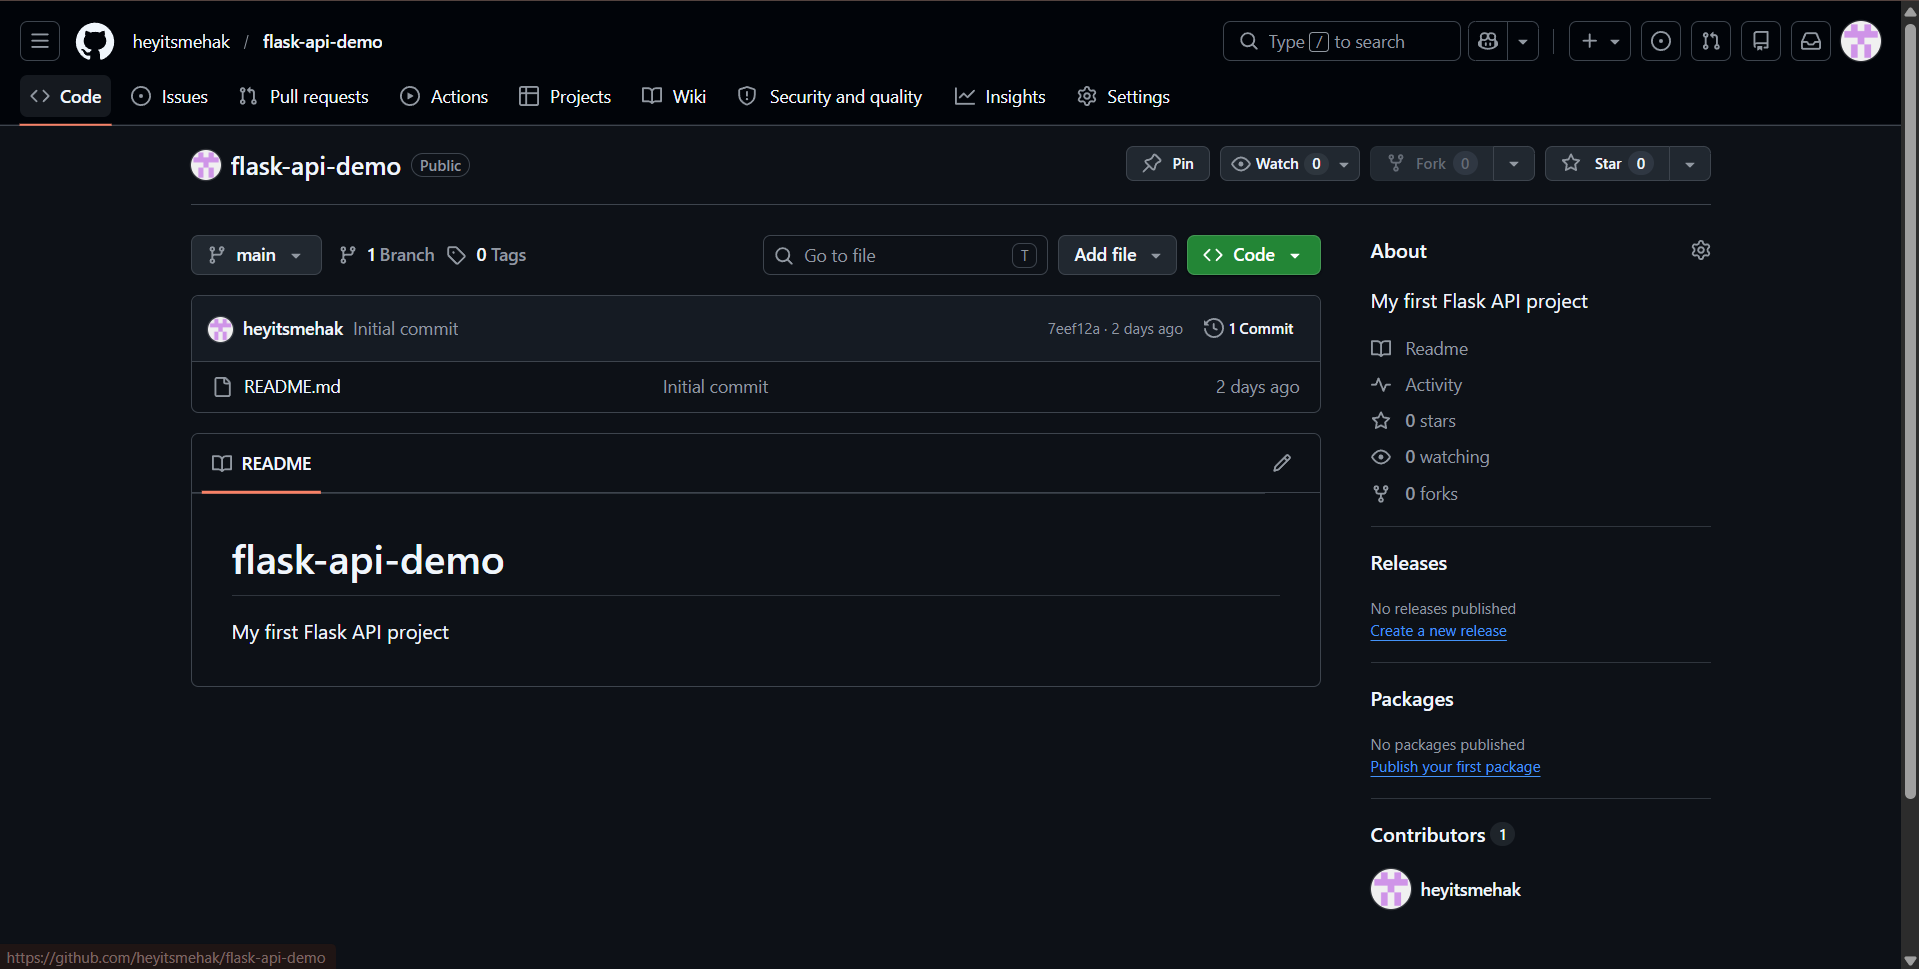







**Step 2: Open GitHub Codespaces**

Inside the repository:

Click:
* Code → Codespaces → Create codespace on main

* Wait for the online VS Code editor to load.





**Step 3: Create a Python File**

In the left sidebar:

* Right Click → New File

* Create file named: main.py





**Step 4: Install Flask**

Open:

* Terminal → New Terminal

* Run the following command: pip install flask

* Press Enter and wait for Flask installation to complete.

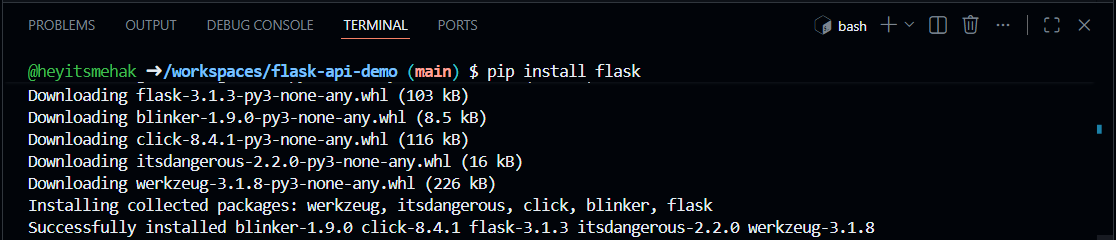

In [ ]:
#Step 1: Install Flask (If Not Installed)
!pip install flask

In [ ]:
#Step 2: Import Required Libraries
from flask import Flask
import random

In [ ]:
#Creating a Flask Application
app = Flask(__name__) #Creates an instance of the Flask app #__ name__ tells Flask to use the current file as the main program.


In [ ]:
#Creating a List of Motivational Quotes
quotes = [
    "Believe in yourself and all that you are.",
    "Don’t watch the clock; do what it does. Keep going.",
    "Every day is a second chance.",
    "Difficulties in life are intended to make us better, not bitter.",
    "The only way to do great work is to love what you do."
]

In [ ]:
#Defining the Homepage Route
@app.route('/')
def home():
    quote = random.choice(quotes)  # Pick a random quote
    return f"<h1>Motivational Quote of the Day</h1><p>{quote}</p>"


In [ ]:
#Running the Flask App in GitHub Codespaces
#if name == "main": → This ensures the Flask app runs only when this file is executed directly.
if __name__ == "__main__":
    app.run(host='0.0.0.0', port=5000, debug=True)
#In GitHub Codespaces, the application runs online inside a cloud-based VS Code environment.
#After running the Flask app, GitHub Codespaces generates a public URL that can be opened in the browser and tested using ReqBin.




 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (inotify)


In [ ]:
#MOTIVATIONAL QUOTES FLASK APP
from flask import Flask
import random

app = Flask(__name__)

# List of motivational quotes
quotes = [
    "Believe in yourself and all that you are.",
    "Don’t watch the clock; do what it does. Keep going.",
    "Every day is a second chance.",
    "Difficulties in life are intended to make us better, not bitter.",
    "The only way to do great work is to love what you do."
]

@app.route('/')
def home():
    quote = random.choice(quotes)  # Pick a random quote
    return f"<h1>Motivational Quote of the Day</h1><p>{quote}</p>"

if __name__ == "__main__":
    app.run(host='0.0.0.0', port=5000, debug=True)

In [ ]:
'''
Step 5: Create and Initialize the Database
Now, we will create a SQLite database (products.db) and add some sample product data using Flask and SQLite inside GitHub Codespaces.
Add the Following Flask + SQLite Code
Copy and paste the following code inside main.py:
'''
from flask import Flask, request, jsonify
import sqlite3

app = Flask(__name__)

# Initialize the database with sample data
def init_db():
    conn = sqlite3.connect('products.db')  # Connect to the database
    cursor = conn.cursor()

    # Create the products table if it does not exist
    cursor.execute('''
    CREATE TABLE IF NOT EXISTS products (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        name TEXT NOT NULL,
        price REAL NOT NULL,
        stock INTEGER NOT NULL
    )
    ''')

    # Check if the table is empty before inserting sample data
    cursor.execute("SELECT COUNT(*) FROM products")
    count = cursor.fetchone()[0]

    if count == 0:
        # Insert default products into the database
        cursor.executemany('''
        INSERT INTO products (name, price, stock) VALUES (?, ?, ?)
        ''', [
            ("Laptop", 75000, 10),
            ("Smartphone", 40000, 20),
            ("Headphones", 2000, 50)
        ])
        print("Inserted default products into the database.")

    conn.commit()
    conn.close()

# Call the database initialization function
init_db()

'''
Step 6: Write a Flask GET API
After initializing the database, we will create an API to retrieve all products.
1️⃣ Add the Following Code Below in main.py
Copy and Paste the Following Code in replit
'''
# Home route
@app.route('/')
def home():
    return "Welcome to the Flask CRUD API! Use `/products` to fetch products."

# GET all products
@app.route('/products', methods=['GET'])
def get_products():
    conn = sqlite3.connect('products.db')
    cursor = conn.cursor()

    # Fetch all products
    cursor.execute('SELECT * FROM products')
    products = cursor.fetchall()

    # Convert database rows to JSON format
    product_list = [
        {"id": row[0], "name": row[1], "price": row[2], "stock": row[3]}
        for row in products
    ]

    conn.close()

    if not product_list:
        return jsonify({"message": "No products found"}), 404

    return jsonify(product_list), 200

# Run the Flask app
if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000, debug=True)

**Step 7: Run the Flask Application**

After adding the code inside main.py:

Click:
* Terminal → New Terminal

* Run the following command: python main.py

* Press Enter.

If everything works correctly, you will see output similar to this:

* Running on http://127.0.0.1:5000
* Debug mode: on

This means your Flask API server is now running successfully inside GitHub Codespaces.

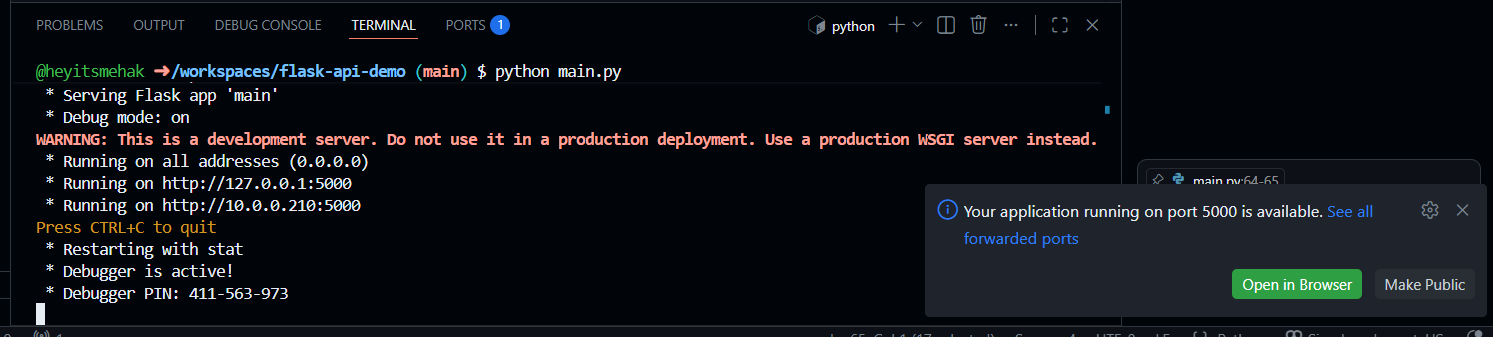